# Negotiation Team Analysis

Compares negotiation **win rate** and **payoff** across four P1 strategies, **faceted per opponent (P2)**.
Every figure replicates the same four-way comparison once for each opponent model the team played against.

| Strategy | Source | P1 party |
|----------|--------|----------|
| **Default** | self_refine `defaultP1_defaultP2` of the **opponent's** model | single instance of the opponent model |
| **Self-Refine** | self_refine `self_refineP1_defaultP2` (RD) of the **opponent's** model | self-refining single instance |
| **Team (homo)** | `negotiation_team/*_homo_v1`, team family matched to the opponent | N copies of the opponent's model |
| **Team (hetero)** | `negotiation_team/*_hetero_v1` | gemma-3-12b-it + Ministral-3-14B + Qwen3-14B |

**Per-opponent framing.** P2 is no longer a fixed default gemma — the team sweeps the `small` opponent tier
(gemma-3-12b-it, qwen3-14b, and mistral once gathered). In each opponent panel the **Default / Self-Refine
baselines are that opponent model's own self-play**, and **Team (homo)** is the homogeneous team built from the
opponent's model family (gemma_x3 in the gemma panel, qwen_x3 in the qwen panel, …). This keeps every panel an
apples-to-apples "single model vs single model" reference for the two team strategies.

Opponents and homo teams are **discovered from disk**, so the mistral opponent and `mistral_x3` homo team appear
automatically once their logs land — no code change needed.


In [23]:
import sys, os, json, glob, warnings
sys.path.insert(0, os.path.abspath("../.."))
sys.path.insert(0, os.path.abspath("../../explorer"))  # for the `analysis` package

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.common import clean_name, resource_value  # reuse explorer/analysis/common.py

warnings.filterwarnings("ignore")
sns.set_context("poster")
sns.set_palette("colorblind")

LOGS_ROOT = os.path.abspath("../../.logs")
SIZE = "small"
GAMES = ["trading", "buysell", "ultimatum"]
GAME_LABEL = {"trading": "Trading", "buysell": "BuySell", "ultimatum": "Ultimatum"}
STRATEGY_ORDER = ["Default", "Self-Refine", "Team (homo)", "Team (hetero)"]

# Map any (cleaned) model id to a coarse family key. Used to (a) match a homogeneous
# team to its opponent panel and (b) order/label opponents. Substring match keeps it
# robust to version drift (e.g. ministral-3-8b vs ministral-3-14b).
FAMILY_ORDER = ["gemma", "qwen", "ministral"]
def model_family(name: str):
    n = name.lower()
    for fam in FAMILY_ORDER:
        if fam in n:
            return fam
    # mistral and ministral both start with "mi"; ministral caught above
    if "mistral" in n:
        return "ministral"
    return n

print("LOGS_ROOT:", LOGS_ROOT, "| exists:", os.path.isdir(LOGS_ROOT))

LOGS_ROOT: /home/adriano/Desktop/MultiAgent-Negotiation/.logs | exists: True


## Payoff helper
Same conventions as `self_refine_analysis.ipynb`.

In [24]:
def payoff_from_summary(game, s):
    """Return (payoff_1, payoff_2) for a completed game's summary.

    - buysell : summary["player_outcome"] = [seller, buyer]
    - trading : net change in total resource value (final - initial)
    - ultimatum: same as trading, then proposer (P1) +100 with no-deal fix (==100 -> 0)
    """
    if game == "buysell":
        outcome = s["player_outcome"]            # [seller, buyer]
        return float(outcome[0]), float(outcome[1])

    d1 = resource_value(s["final_resources"][0]) - resource_value(s["initial_resources"][0])
    d2 = resource_value(s["final_resources"][1]) - resource_value(s["initial_resources"][1])

    if game == "ultimatum":
        d1 += 100
        if d1 == 100:        # no deal -> proposer keeps nothing
            d1 = 0
    return float(d1), float(d2)

## Loaders
One tidy long DataFrame: one row per completed run, P1-focal.

In [25]:
def _iter_game_states(root):
    """Yield (path, summary) for every COMPLETED run under `root`."""
    for path in glob.glob(os.path.join(root, "**", "game_state.json"), recursive=True):
        try:
            with open(path) as f:
                data = json.load(f)
        except Exception:
            continue
        last = data["game_state"][-1]
        if last.get("current_iteration") != "END":
            continue
        summary = last.get("summary")
        if summary is None:          # completed but no usable outcome
            continue
        yield path, summary


def _row(game, strategy, path, summary, opponent=None, team_base=None):
    p1, p2 = payoff_from_summary(game, summary)
    return {"game": game, "strategy": strategy,
            "opponent": opponent, "team_base": team_base,
            "run_id": os.path.basename(os.path.dirname(path)),
            "payoff_1": p1, "payoff_2": p2}


def _parse_team_folder(path):
    """Extract (team_raw, opp_raw) from the 'team_<TEAM>_vs_<OPP>' path segment.

    Returns (None, None) if no such segment is found.
      homo  : team_gemma-3-12b-it_x3_vs_gemma-3-12b-it           -> ('gemma-3-12b-it_x3', 'gemma-3-12b-it')
      hetero: team_gemma-3-12b-it+ministral...+qwen3-14b_vs_qwen3-14b -> ('gemma...+qwen3-14b', 'qwen3-14b')
    """
    for part in path.split(os.sep):
        if part.startswith("team_") and "_vs_" in part:
            team_raw, opp_raw = part[len("team_"):].rsplit("_vs_", 1)
            return team_raw, opp_raw
    return None, None


def load_team(game, variant):
    """variant in {'homo','hetero'} -> rows tagged 'Team (homo)'/'Team (hetero)',
    each carrying its parsed `opponent` (cleaned) and `team_base`.

    homo team_base = the (cleaned) single model the team is N copies of;
    hetero team_base = 'trio'. No merging across opponents/teams happens here.
    """
    label = f"Team ({variant})"
    root = os.path.join(LOGS_ROOT, "negotiation_team",
                        f"{game}_negotiation_team_{variant}_v1", SIZE)
    rows = []
    for path, summary in _iter_game_states(root):
        team_raw, opp_raw = _parse_team_folder(path)
        if opp_raw is None:
            continue
        if variant == "homo":
            team_base = clean_name(team_raw.split("_x3")[0])
        else:
            team_base = "trio"
        rows.append(_row(game, label, path, summary,
                         opponent=clean_name(opp_raw), team_base=team_base))
    return rows


def load_baseline(game, model_id, cond_suffix, label):
    """Pull `model_id`-vs-`model_id` self-play runs for one self_refine condition.

    trading/ultimatum encode the condition in the model-pair folder
    (e.g. ..._self_refineP1_defaultP2); buysell nests it as seller40_buyer60_<cond>.
    Match on: some path segment starts with the <model>_vs_<model> pair AND
    some segment ends with the condition suffix. Rows are tagged with the
    opponent (= the baselined model) so they land in the right per-opponent panel.
    """
    root = os.path.join(LOGS_ROOT, "self_refine", f"{game}_self_refine_v1", SIZE)
    pair = f"{model_id}_vs_{model_id}"
    rows = []
    for path, summary in _iter_game_states(root):
        parts = path.split(os.sep)
        has_pair = any(p.startswith(pair) for p in parts)
        has_cond = any(p.endswith(cond_suffix) for p in parts)
        if has_pair and has_cond:
            rows.append(_row(game, label, path, summary, opponent=clean_name(model_id)))
    return rows


def discover_opponents():
    """Raw opponent ids present across all team logs, family-ordered.

    Returns e.g. ['gemma-3-12b-it', 'qwen3-14b'] (+ mistral once gathered).
    These raw ids double as the self_refine baseline model ids.
    """
    opps = set()
    for game in GAMES:
        for variant in ("homo", "hetero"):
            root = os.path.join(LOGS_ROOT, "negotiation_team",
                                f"{game}_negotiation_team_{variant}_v1", SIZE)
            if not os.path.isdir(root):
                continue
            for d in os.listdir(root):
                if d.startswith("team_") and "_vs_" in d:
                    opps.add(d.rsplit("_vs_", 1)[1])

    def _key(o):
        fam = model_family(clean_name(o))
        return (FAMILY_ORDER.index(fam) if fam in FAMILY_ORDER else 99, o)
    return sorted(opps, key=_key)


def build_df():
    opp_ids = discover_opponents()

    # All team rows (every opponent), filtered to matched panels below.
    team_rows = []
    for game in GAMES:
        team_rows += load_team(game, "homo")
        team_rows += load_team(game, "hetero")
    team_df = pd.DataFrame(team_rows)

    # Per-opponent baselines: each opponent model's own self-play.
    base_rows = []
    for opp_id in opp_ids:
        for game in GAMES:
            base_rows += load_baseline(game, opp_id, "defaultP1_defaultP2", "Default")
            base_rows += load_baseline(game, opp_id, "self_refineP1_defaultP2", "Self-Refine")
    base_df = pd.DataFrame(base_rows)

    # Per opponent: keep hetero (all) + homo whose base family matches the opponent.
    keep = []
    for opp_id in opp_ids:
        opp = clean_name(opp_id)
        fam = model_family(opp)
        sub = team_df[team_df["opponent"] == opp]
        keep.append(sub[sub["strategy"] == "Team (hetero)"])
        keep.append(sub[(sub["strategy"] == "Team (homo)") &
                        (sub["team_base"].map(model_family) == fam)])
    team_keep = pd.concat(keep, ignore_index=True) if keep else team_df.iloc[0:0]

    df = pd.concat([base_df, team_keep], ignore_index=True)
    df["win_1"] = df["payoff_1"] > df["payoff_2"]
    df["win_2"] = df["payoff_2"] > df["payoff_1"]
    df["draw"]  = df["payoff_1"] == df["payoff_2"]
    df["strategy"] = pd.Categorical(df["strategy"], categories=STRATEGY_ORDER, ordered=True)
    df["game"] = pd.Categorical(df["game"], categories=GAMES, ordered=True)
    df["opponent"] = pd.Categorical(df["opponent"],
                                    categories=[clean_name(o) for o in opp_ids], ordered=True)
    return df


OPPONENTS = [clean_name(o) for o in discover_opponents()]
print("opponents discovered:", OPPONENTS)

df = build_df()
print("rows:", len(df))
df.head()

opponents discovered: ['gemma-3-12b-it', 'qwen3-14b']


rows: 661


,game,strategy,opponent,team_base,run_id,payoff_1,payoff_2,win_1,win_2,draw
0,trading,Default,gemma-3-12b-it,None,1779033809585,-1.0,1.0,False,True,False
1,trading,Default,gemma-3-12b-it,None,1779032293732,-2.0,2.0,False,True,False
2,trading,Default,gemma-3-12b-it,None,1779034769422,-5.0,5.0,False,True,False
3,trading,Default,gemma-3-12b-it,None,1779038398618,2.0,-2.0,True,False,False
4,trading,Default,gemma-3-12b-it,None,1779033544421,-8.0,8.0,False,True,False


## Sample sizes
Run counts per opponent × game × strategy (the denominators behind every plot below).

In [26]:
counts = df.pivot_table(index=["opponent", "game"], columns="strategy", values="run_id",
                        aggfunc="count", observed=True)
counts

strategy                  Default  Self-Refine  Team (homo)  Team (hetero)
opponent       game                                                       
gemma-3-12b-it trading         30           29           29             28
               buysell         30           29           30             30
               ultimatum       30           29           30             30
qwen3-14b      trading         20           14           29             24
               buysell         24           30           30             27
               ultimatum       19           30           30             30

## P1 win rate
Strict P1 wins (`payoff_1 > payoff_2`), one panel per opponent. Draw rate reported below.

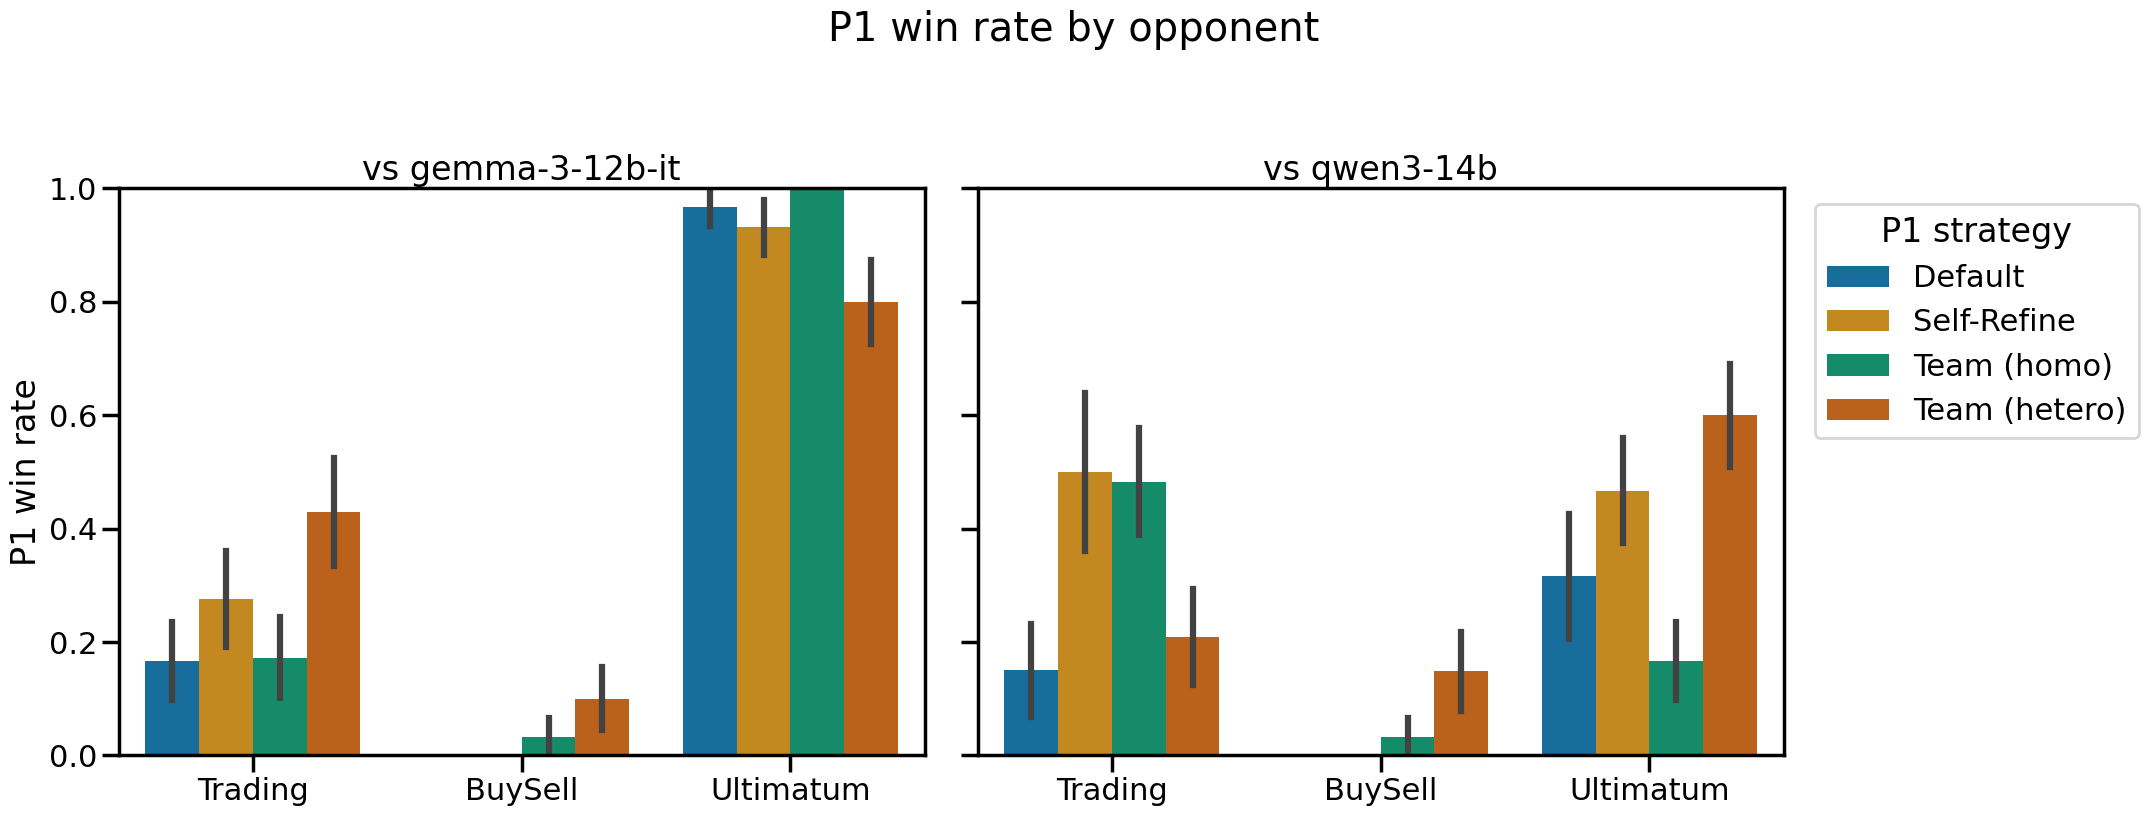

Draw rate per opponent x game x strategy:


strategy                  Default  Self-Refine  Team (homo)  Team (hetero)
opponent       game                                                       
gemma-3-12b-it trading       0.10         0.03         0.03           0.04
               buysell       0.17         0.03         0.03           0.30
               ultimatum     0.03         0.07         0.00           0.17
qwen3-14b      trading       0.55         0.14         0.38           0.04
               buysell       0.12         0.07         0.20           0.22
               ultimatum     0.68         0.43         0.77           0.33

In [27]:
# One panel per opponent; within each: x=game, hue=strategy. Shared y in [0,1].
opps = [o for o in OPPONENTS if not df[df["opponent"] == o].empty]
fig, axes = plt.subplots(1, len(opps), figsize=(11 * len(opps), 8), sharey=True, squeeze=False)
axes = axes[0]
for ax, opp in zip(axes, opps):
    sub = df[df["opponent"] == opp]
    sns.barplot(data=sub, x="game", y="win_1", hue="strategy",
                hue_order=STRATEGY_ORDER, errorbar="se", ax=ax,
                legend=(opp == opps[-1]))
    ax.set_title(f"vs {opp}")
    ax.set_xlabel(""); ax.set_ylim(0, 1)
    ax.set_ylabel("P1 win rate" if opp == opps[0] else "")
    ax.set_xticklabels([GAME_LABEL[t.get_text()] for t in ax.get_xticklabels()])
axes[-1].legend(title="P1 strategy", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("P1 win rate by opponent", y=1.04)
plt.tight_layout()
#fig.savefig("negotiation_team_win_rate_by_opponent.png", bbox_inches="tight")  # save BEFORE show()
plt.show()

print("Draw rate per opponent x game x strategy:")
df.pivot_table(index=["opponent", "game"], columns="strategy", values="draw",
               aggfunc="mean", observed=True).round(2)

## P1 payoff
Payoff scales differ per game, so each (opponent, game) gets its own panel — rows are opponents, columns are games.

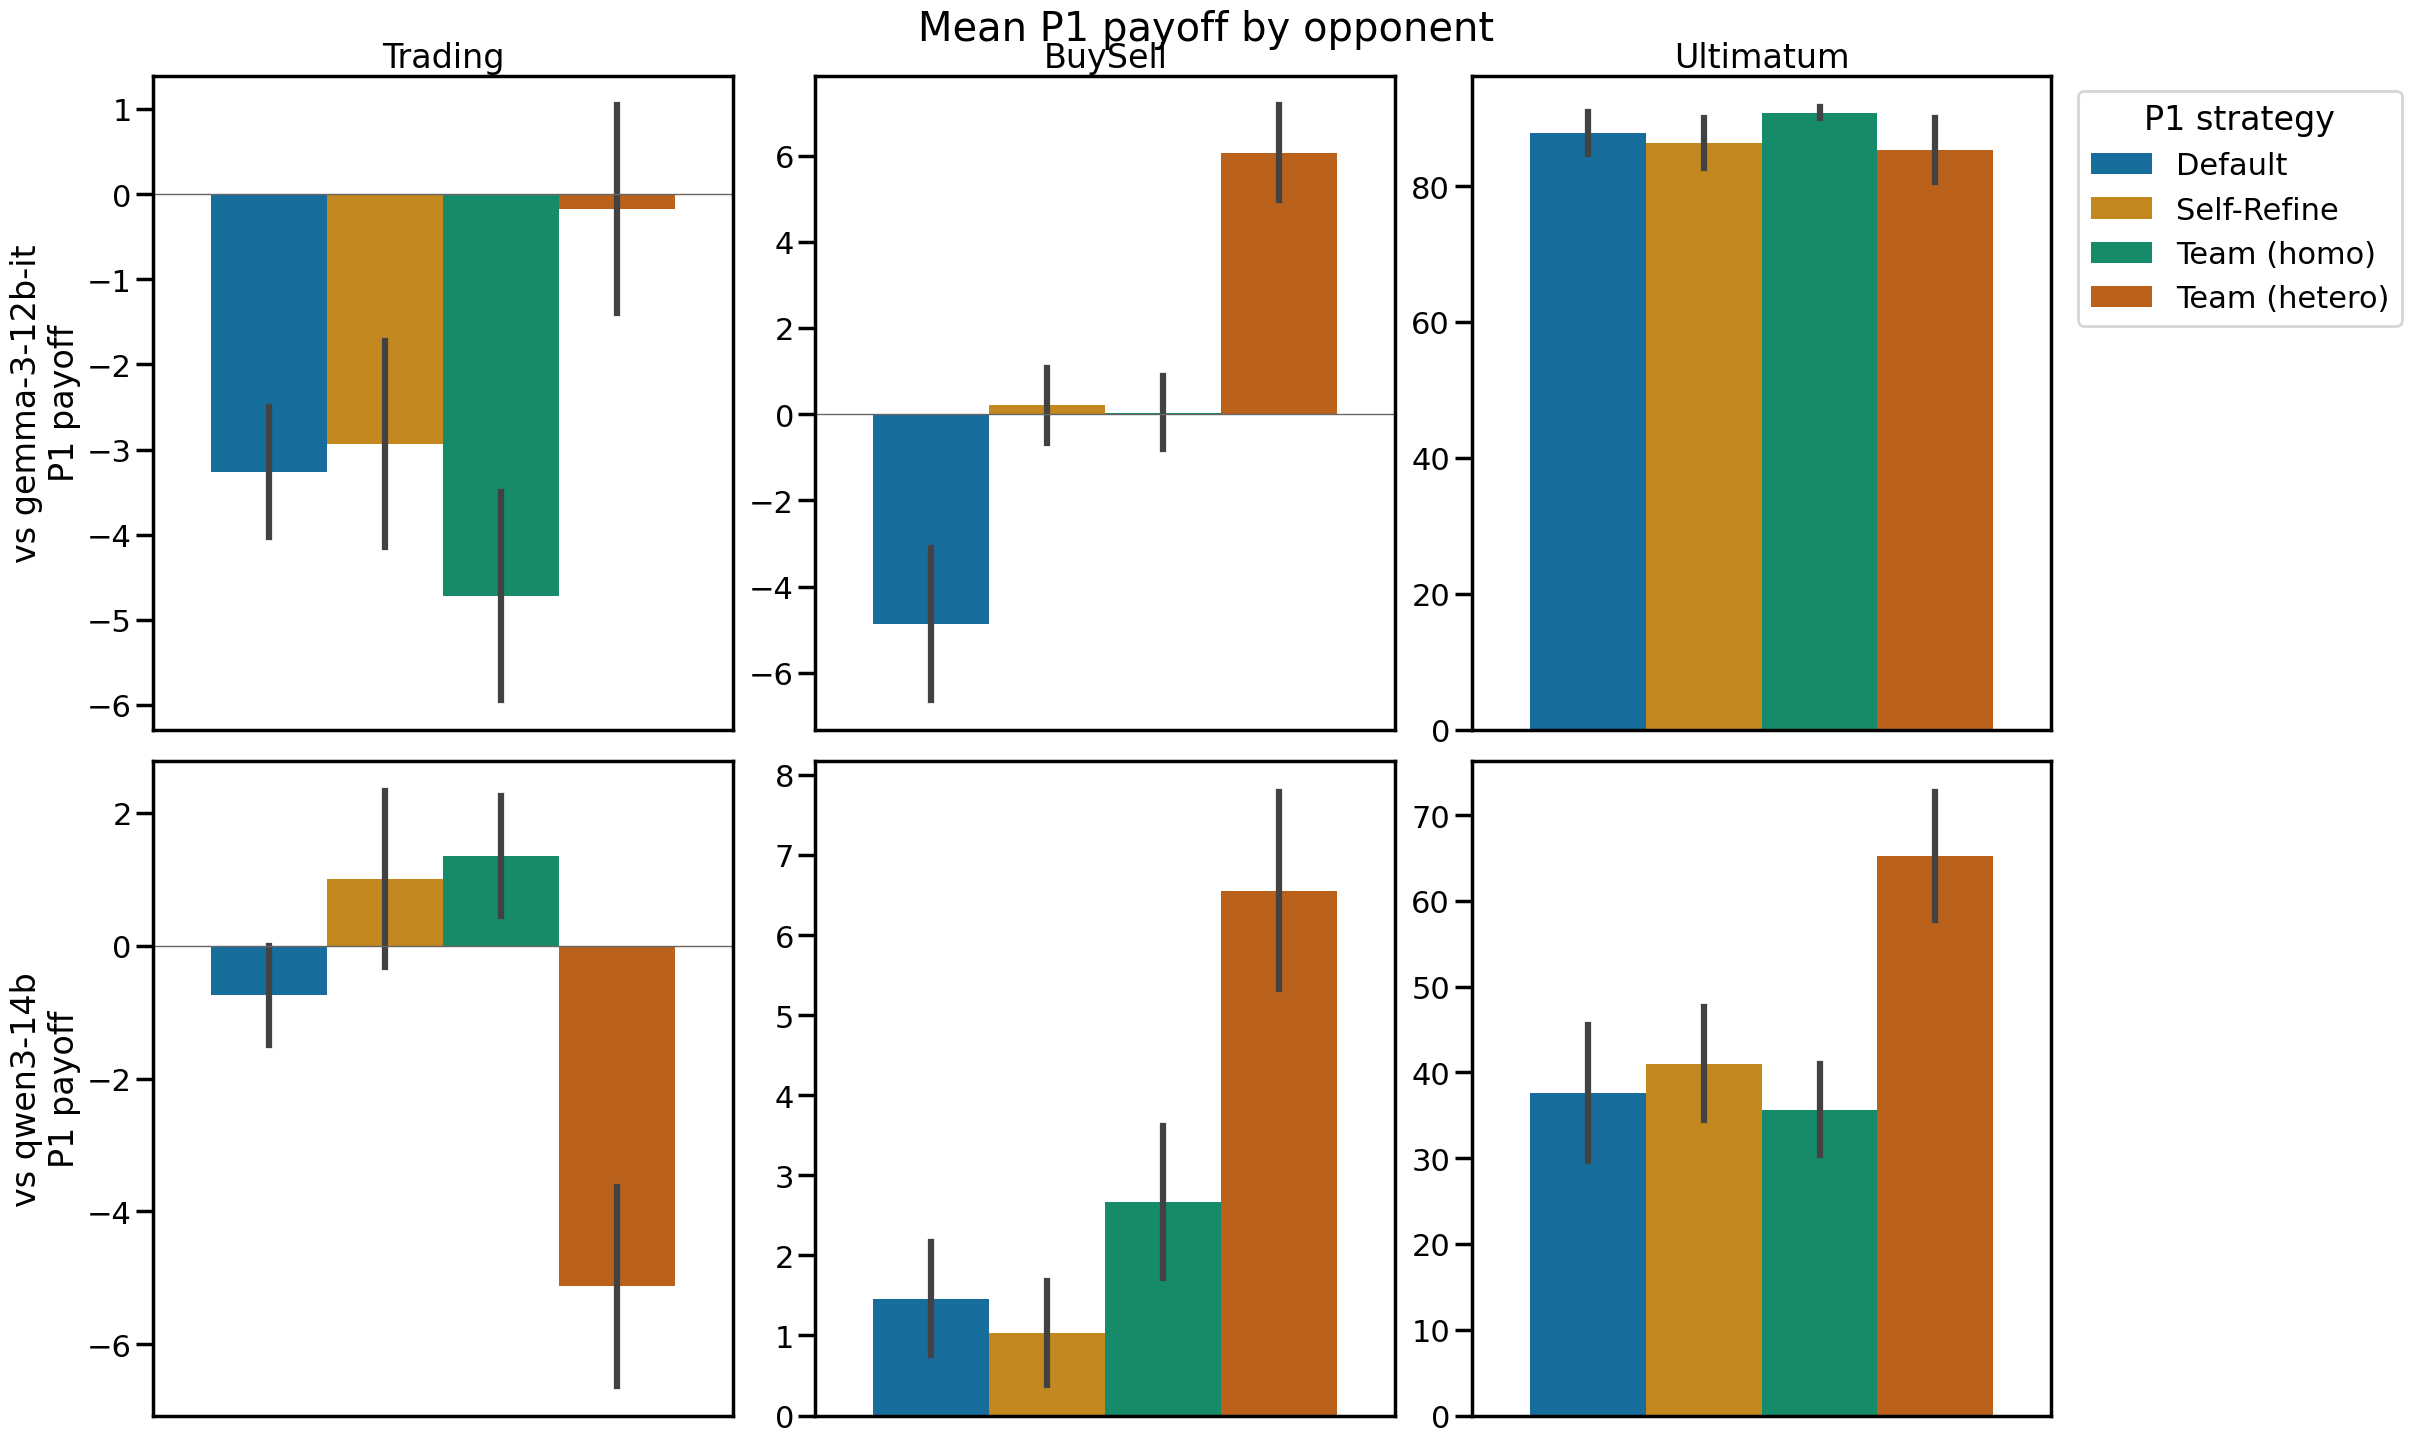

In [28]:
# Grid: rows = opponent, cols = game. Independent y per game (payoffs can be negative).
opps = [o for o in OPPONENTS if not df[df["opponent"] == o].empty]
nrows, ncols = len(opps), len(GAMES)
fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 7 * nrows),
                         squeeze=False, constrained_layout=True)
for r, opp in enumerate(opps):
    for c, game in enumerate(GAMES):
        ax = axes[r][c]
        sub = df[(df["opponent"] == opp) & (df["game"] == game)].copy()
        sub["_x"] = GAME_LABEL[game]  # single category -> hued bars centered
        last_panel = (r == 0 and c == ncols - 1)
        sns.barplot(data=sub, x="_x", y="payoff_1", hue="strategy",
                    hue_order=STRATEGY_ORDER, errorbar="se", ax=ax, legend=last_panel)
        ax.axhline(0, color="0.4", lw=1)
        ax.set_xlabel(""); ax.set_xticks([])
        ax.set_title(GAME_LABEL[game] if r == 0 else "")
        ax.set_ylabel(f"vs {opp}\nP1 payoff" if c == 0 else "")
axes[0][-1].legend(title="P1 strategy", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Mean P1 payoff by opponent", y=1.02)
#fig.savefig("negotiation_team_payoff_by_opponent_and_game.png", bbox_inches="tight")  # save BEFORE show()
plt.show()

## Homogeneous vs Heterogeneous teams
Zoom on the two team strategies, faceted per opponent (win rate top row, payoff bottom row).

> **Matched-panel rule:** in each opponent panel, `Team (homo)` is the homogeneous team whose model family
> matches the opponent (gemma_x3 vs gemma, qwen_x3 vs qwen, …). Cross-family homo runs (e.g. ministral_x3 vs
> qwen), should any be gathered, are intentionally excluded from these matched panels.

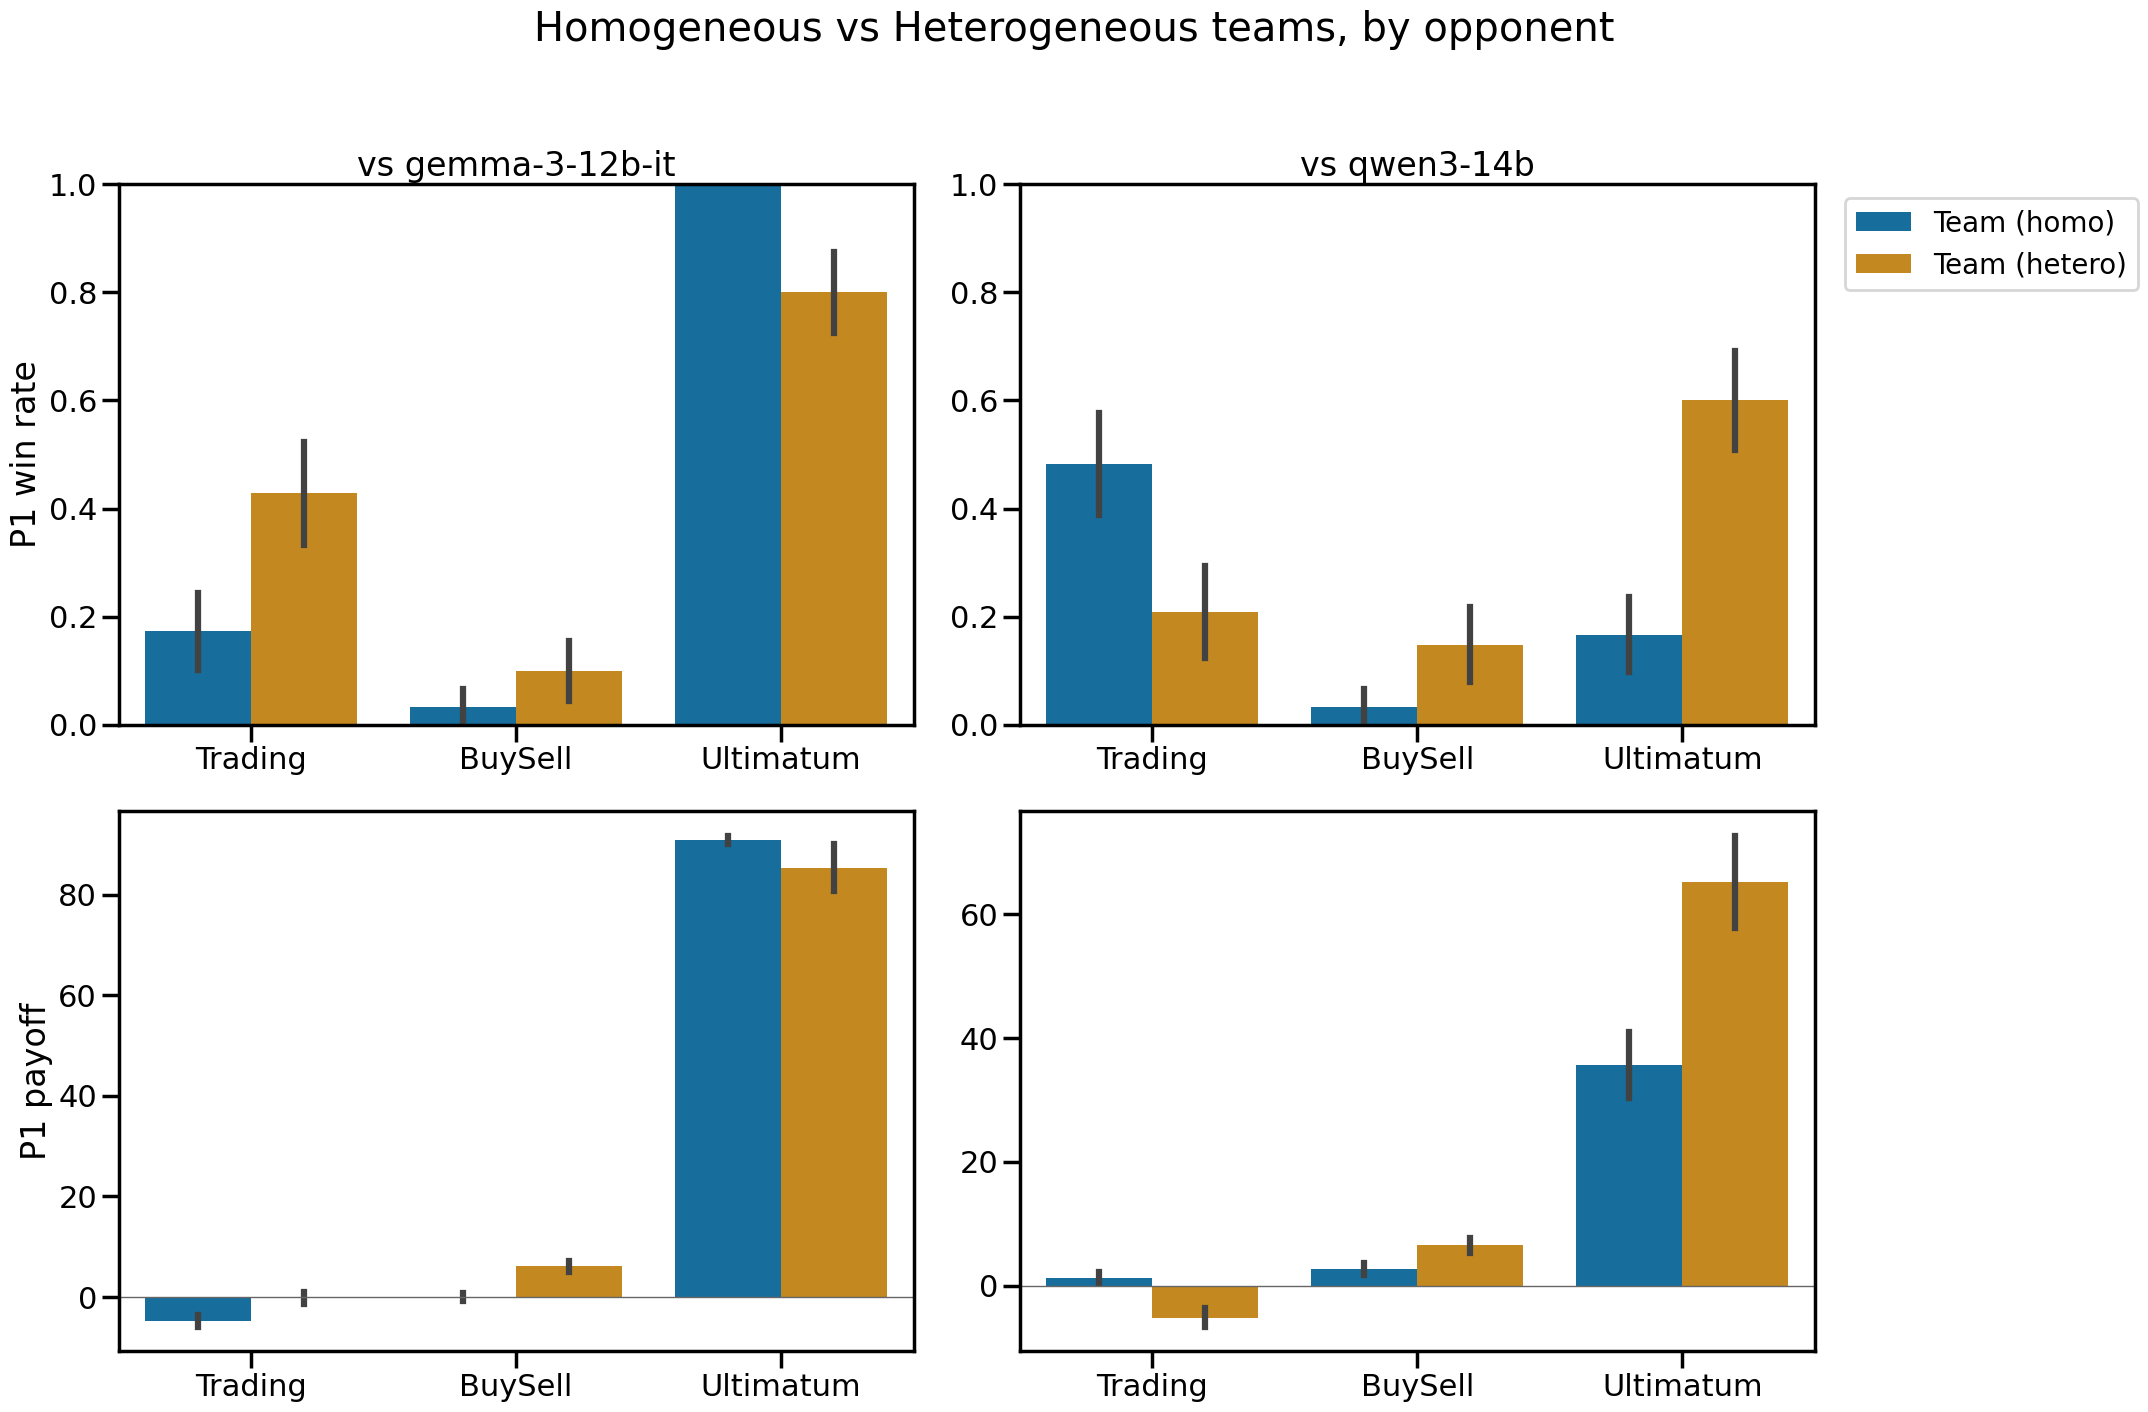

In [29]:
# Zoom on the two team strategies, faceted per opponent.
# Rows: win rate / payoff; columns: opponent.
teams = df[df["strategy"].isin(["Team (homo)", "Team (hetero)"])].copy()
teams["strategy"] = teams["strategy"].cat.remove_unused_categories()
opps = [o for o in OPPONENTS if not teams[teams["opponent"] == o].empty]

fig, axes = plt.subplots(2, len(opps), figsize=(11 * len(opps), 14), squeeze=False)
for c, opp in enumerate(opps):
    sub = teams[teams["opponent"] == opp]
    sns.barplot(data=sub, x="game", y="win_1", hue="strategy", errorbar="se",
                ax=axes[0][c], legend=(c == len(opps) - 1))
    axes[0][c].set_title(f"vs {opp}")
    axes[0][c].set_ylim(0, 1); axes[0][c].set_xlabel("")
    axes[0][c].set_ylabel("P1 win rate" if c == 0 else "")

    sns.barplot(data=sub, x="game", y="payoff_1", hue="strategy", errorbar="se",
                ax=axes[1][c], legend=False)
    axes[1][c].axhline(0, color="0.4", lw=1); axes[1][c].set_xlabel("")
    axes[1][c].set_ylabel("P1 payoff" if c == 0 else "")

for ax in axes.flat:
    ax.set_xticklabels([GAME_LABEL[t.get_text()] for t in ax.get_xticklabels()])
axes[0][-1].legend(title="", fontsize="small", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.suptitle("Homogeneous vs Heterogeneous teams, by opponent", y=1.02)
plt.tight_layout()
#fig.savefig("negotiation_team_homo_vs_hetero_by_opponent.png", bbox_inches="tight")  # save BEFORE show()
plt.show()